# Phylogenetic mean on a real tree

In this notebook we load a small primate phylogeny from a Newick string, seed the leaves with a trait value (brain volume, in cm³), and run the `phylo_mean` prebuilt to infer the trait at every internal node — the **ancestral state reconstruction** problem of comparative biology.

Along the way you'll see:

- `hyperiax.io.newick.read` — Newick string / file → `Tree`
- How BFS-ordered node indices relate to leaves named in the Newick source
- The `phylo_mean` prebuilt: each parent's value = edge-length-weighted mean of its children, which is the closed-form estimator under a Brownian-motion model of trait evolution
- A comparison against a naïve recursive average to see why edge-length weighting matters
- `hyperiax.io.newick.write` — round-trip back out to a Newick string

The maths is light; the focus is end-to-end workflow on a tree that looks like the ones you'd actually use.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx
from hyperiax.io import newick
from hyperiax.prebuilt import phylo_mean


def _dfs_x_positions(topo):
    """DFS left-to-right ordering of leaves → x ∈ [0, 1]."""
    xs = np.zeros(topo.size)
    next_leaf = [0]
    n_leaves = int(topo.is_leaf.sum())
    def visit(node):
        if topo.is_leaf[node]:
            xs[node] = next_leaf[0] / max(1, n_leaves - 1)
            next_leaf[0] += 1
            return xs[node]
        # children of `node` in BFS order — ete3 BFS preserves Newick child order.
        children = [i for i in range(1, topo.size) if int(topo.parents[i]) == int(node)]
        cx = [visit(c) for c in children]
        xs[node] = float(np.mean(cx))
        return xs[node]
    visit(0)
    return xs


def plot_phylo_tree(topo, values=None, edge_lengths=None, ax=None, title=None,
                    cmap='viridis', vmin=None, vmax=None,
                    show_branch_labels=False, value_fmt='{:.0f}'):
    """Cladogram-style phylo tree drawing with leaf species names.

    Uses cumulative edge length as y when ``edge_lengths`` is given
    (proper time-tree), else falls back to ``-node_depth``. Leaf labels
    are read from ``topo.names``.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    pos = np.zeros((topo.size, 2))
    pos[:, 0] = _dfs_x_positions(topo)
    if edge_lengths is not None:
        age = np.zeros(topo.size)
        for i in range(1, topo.size):
            age[i] = age[int(topo.parents[i])] + float(edge_lengths[i])
        pos[:, 1] = -age
    else:
        pos[:, 1] = -np.asarray(topo.node_depths)
    # right-angled edges (cladogram style)
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0], pos[i, 0]],
                [pos[p, 1], pos[p, 1], pos[i, 1]],
                'k-', lw=0.9, alpha=0.6, zorder=1)
        if show_branch_labels and edge_lengths is not None:
            mid_y = (pos[p, 1] + pos[i, 1]) / 2
            ax.text(pos[i, 0] + 0.012, mid_y,
                    f'{float(edge_lengths[i]):.1f}', fontsize=7, color='gray',
                    ha='left', va='center')
    # node markers
    if values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=260, c='lightsteelblue',
                   edgecolor='k', zorder=3)
    else:
        v = np.asarray(values)
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=320, c=v,
                        edgecolor='k', cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)
        plt.colorbar(sc, ax=ax, shrink=0.7, label='value')
    # text overlays
    names = topo.names if topo.names is not None else ('',) * topo.size
    for i in range(topo.size):
        if values is not None:
            ax.text(pos[i, 0], pos[i, 1], value_fmt.format(float(np.asarray(values)[i])),
                    ha='center', va='center', fontsize=7, color='white', zorder=4)
        if topo.is_leaf[i] and names[i]:
            ax.annotate(names[i], (pos[i, 0], pos[i, 1]),
                        xytext=(0, -14), textcoords='offset points',
                        ha='center', va='top', fontsize=9, zorder=4)
    if title:
        ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    return ax

## 1. Load a Newick tree

Our test tree is a small primate phylogeny — five great apes plus a gibbon — with branch lengths in millions of years (Ma), roughly consistent with the consensus divergence times on [TimeTree.org](http://www.timetree.org/):

| Split | Approx. age |
|---|---|
| Human–Chimp | 6.5 Ma |
| +Gorilla | 8.5 Ma |
| +Orangutan | 14.5 Ma |
| +Gibbon | 20 Ma |

Note that this is an **ultrametric tree**: every leaf sits 20 Ma below the root (the present is at the bottom of the tree).

In [2]:
PRIMATE_NEWICK = '((((Human:6.5,Chimp:6.5):2,Gorilla:8.5):6,Orangutan:14.5):5.5,Gibbon:20);'

tree = newick.read(PRIMATE_NEWICK, schema={'estimated_value': ()})
print(tree)
print()
print(f"size:         {tree.topology.size}")
print(f"depth:        {tree.topology.depth}")
print(f"equal_degree: {tree.topology.equal_degree}")
print(f"leaves:       {int(tree.topology.is_leaf.sum())}")

Tree(size=9, fields={edge_length: (), estimated_value: ()})

size:         9
depth:        4
equal_degree: True
leaves:       5


### How Newick nodes map to BFS indices

The Newick parser produces a BFS-ordered topology — node `0` is the root, and `parents[i] < i` for `i > 0`. The names you wrote in the Newick string land on `topo.names`, and the colon-separated branch lengths land on `tree.edge_length`. Internal nodes have no name (empty string).

In [3]:
topo = tree.topology
print(f"{'idx':>3}  {'name':<10}  {'parent':>6}  {'edge_len':>8}  {'depth':>5}  {'leaf?':>5}")
print('-' * 50)
for i in range(topo.size):
    name = topo.names[i] or '(inner)'
    leaf = 'yes' if topo.is_leaf[i] else ''
    print(f"{i:>3}  {name:<10}  {int(topo.parents[i]):>6}  {float(tree.edge_length[i]):>8.2f}  {int(topo.node_depths[i]):>5}  {leaf:>5}")

idx  name        parent  edge_len  depth  leaf?
--------------------------------------------------
  0  (inner)          0      0.00      0       
  1  (inner)          0      5.50      1       
  2  Gibbon           0     20.00      1    yes
  3  (inner)          1      6.00      2       
  4  Orangutan        1     14.50      2    yes
  5  (inner)          3      2.00      3       
  6  Gorilla          3      8.50      3    yes
  7  Human            5      6.50      4    yes
  8  Chimp            5      6.50      4    yes


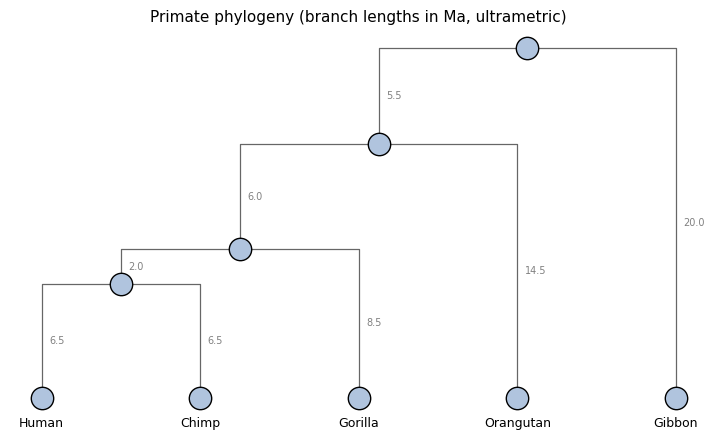

In [4]:
plot_phylo_tree(topo, edge_lengths=tree.edge_length,
                title='Primate phylogeny (branch lengths in Ma, ultrametric)',
                show_branch_labels=True)
plt.show()

## 2. Seed leaves with a trait

For ancestral state reconstruction we need observed leaf values. We'll use endocranial volume (cm³) — a continuous trait that's easy to imagine and has a famous outlier (us).

| Species | Brain volume (cm³) |
|---|---|
| Human | 1350 |
| Chimp | 400 |
| Gorilla | 500 |
| Orangutan | 400 |
| Gibbon | 100 |

The numbers are rough literature averages; the point is just that one species (us) is 3-4× the others.

In [5]:
BRAIN_VOL = {
    'Human':     1350.0,
    'Chimp':      400.0,
    'Gorilla':    500.0,
    'Orangutan':  400.0,
    'Gibbon':     100.0,
}

# Look up each leaf's index from topo.names so we don't hard-code BFS order.
leaf_indices = np.where(topo.is_leaf)[0]
leaf_values = jnp.asarray(
    [BRAIN_VOL[topo.names[i]] for i in leaf_indices], dtype=jnp.float32
)

tree = tree.at[topo.is_leaf].set(estimated_value=leaf_values)
print('estimated_value (inner nodes are still zero):')
for i in range(topo.size):
    print(f'  node {i:>2} {topo.names[i] or "(inner)":<10}  {float(tree.estimated_value[i]):>8.1f}')

estimated_value (inner nodes are still zero):
  node  0 (inner)          0.0
  node  1 (inner)          0.0
  node  2 Gibbon         100.0
  node  3 (inner)          0.0
  node  4 Orangutan      400.0
  node  5 (inner)          0.0
  node  6 Gorilla        500.0
  node  7 Human         1350.0
  node  8 Chimp          400.0


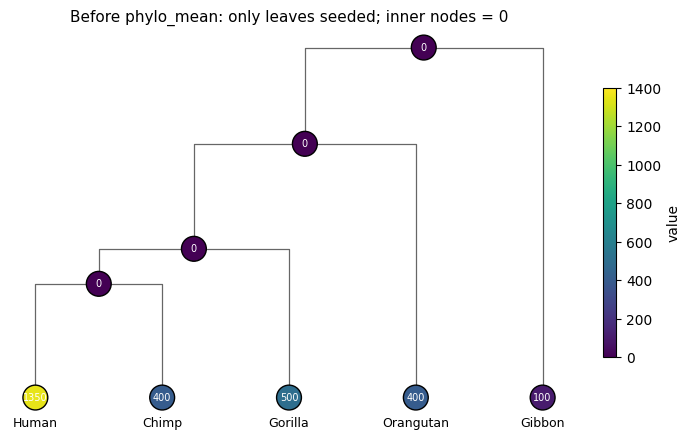

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_phylo_tree(topo, values=tree.estimated_value, edge_lengths=tree.edge_length,
                ax=ax, vmin=0, vmax=1400,
                title='Before phylo_mean: only leaves seeded; inner nodes = 0')
plt.show()

## 3. Run `phylo_mean`

The prebuilt sweep computes, at every parent:

$$\hat{x}_p = \frac{\sum_c x_c / \ell_c}{\sum_c 1 / \ell_c}$$

where the sum is over the parent's children $c$ and $\ell_c$ is the branch length connecting $c$ to $p$. Short edges → high weight (sister taxa pull the ancestor toward themselves); long edges → low weight (distant relatives contribute less). It is the maximum-likelihood estimator for the parent's state under a Brownian-motion model of trait evolution along edges.

Implementation-wise it's a single `@hx.up` sweep that reads `children.estimated_value` and `children.edge_length` and writes `estimated_value` back. We saw the explicit version in `02_writing_sweeps.ipynb`; here we just import the prebuilt and call it.

In [7]:
sweep = phylo_mean()
inferred = sweep(tree)

print('inferred values per node:')
for i in range(topo.size):
    label = topo.names[i] or '(inner)'
    print(f'  node {i:>2} {label:<10}  {float(inferred.estimated_value[i]):>8.1f}')

print()
print(f"Root (LCA of all 5 species) estimate: {float(inferred.estimated_value[0]):.1f} cm³")

inferred values per node:
  node  0 (inner)        559.2
  node  1 (inner)        685.5
  node  2 Gibbon         100.0
  node  3 (inner)        803.6
  node  4 Orangutan      400.0
  node  5 (inner)        875.0
  node  6 Gorilla        500.0
  node  7 Human         1350.0
  node  8 Chimp          400.0

Root (LCA of all 5 species) estimate: 559.2 cm³


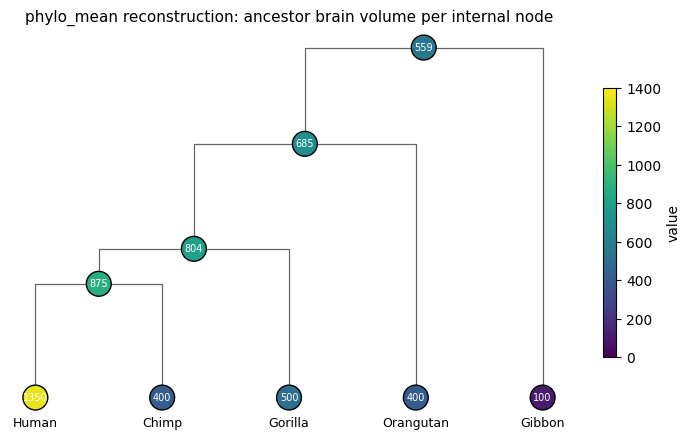

In [8]:
plot_phylo_tree(topo, values=inferred.estimated_value, edge_lengths=tree.edge_length,
                vmin=0, vmax=1400,
                title='phylo_mean reconstruction: ancestor brain volume per internal node')
plt.show()

## 4. Compare with a naïve recursive mean

How much did the edge-length weighting actually matter? Let's run a baseline that uses `children.value.mean(0)` — every child contributes equally regardless of branch length — and compare the two reconstructions on the same tree.

In [9]:
@hx.up(reads_children=('estimated_value',), writes=('estimated_value',))
def naive_mean(node, children, params):
    return {'estimated_value': children.estimated_value.mean(0)}

naive = naive_mean(tree)

flat = float(jnp.mean(leaf_values))

print(f"{'method':<20} {'root est. (cm³)':>15}")
print('-' * 38)
print(f"{'phylo_mean':<20} {float(inferred.estimated_value[0]):>15.1f}")
print(f"{'naive recursive':<20} {float(naive.estimated_value[0]):>15.1f}")
print(f"{'flat leaf mean':<20} {flat:>15.1f}")

method               root est. (cm³)
--------------------------------------
phylo_mean                     559.2
naive recursive                321.9
flat leaf mean                 550.0


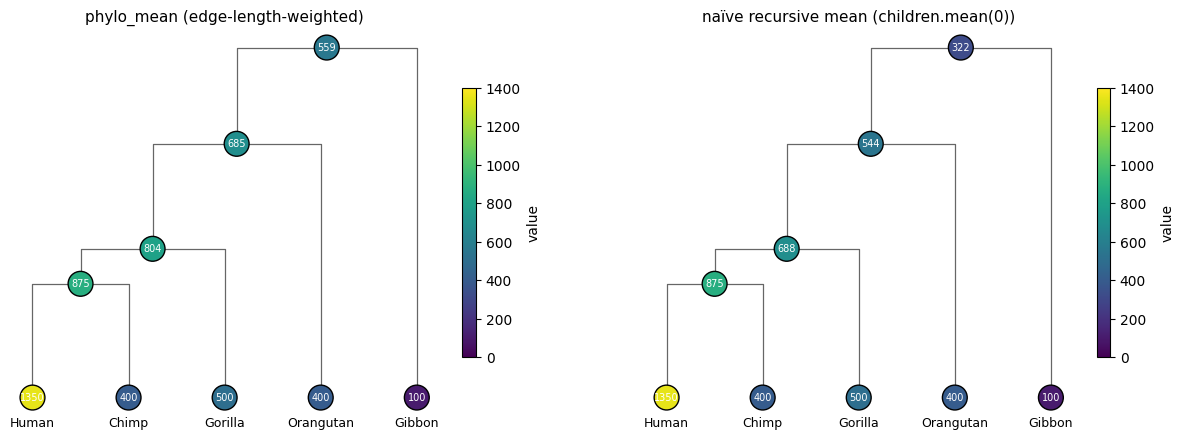

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_phylo_tree(topo, values=inferred.estimated_value, edge_lengths=tree.edge_length,
                ax=axes[0], vmin=0, vmax=1400,
                title='phylo_mean (edge-length-weighted)')
plot_phylo_tree(topo, values=naive.estimated_value, edge_lengths=tree.edge_length,
                ax=axes[1], vmin=0, vmax=1400,
                title='naïve recursive mean (children.mean(0))')
plt.show()

What you should see:

- **Naïve recursive mean is heavily biased by tree shape.** At the root, it averages Gibbon (100) with the 4-ape subtree's recursive mean — but the 4-ape subtree's mean is already a recursive average that propagates Human's outlier value through three levels of halving, so the value reaching the root from the apes side is much smaller than the flat leaf mean. The Gibbon side then drags it down further. Result is far below the flat leaf mean of 550.
- **`phylo_mean` is much closer to the flat leaf mean** because the inverse-edge-length weighting compensates for tree imbalance. The 4-ape side has many short edges (high weight) and one long edge through Gibbon (low weight, 1/20 = 0.05). Gibbon contributes little; the apes contribute a lot — and the apes' average pulls the root estimate up.

Neither is the "true" ancestral brain volume — that would require a full evolutionary model and is impossible to know without fossils. The point is that **how you propagate up the tree matters**, and `phylo_mean` is the structure-aware default.

## 5. Round-trip back to Newick

`newick.write` converts the tree (including any updated `edge_length`) back to a Newick string. Internal node names that we never set come out as `""`. The inferred `estimated_value` field doesn't appear in the Newick output — it isn't part of the format.

In [11]:
round_tripped = newick.write(inferred)
print('original:    ', PRIMATE_NEWICK)
print('round-tripped:', round_tripped)
print()
print(f'identical?    {round_tripped == PRIMATE_NEWICK}')

original:     ((((Human:6.5,Chimp:6.5):2,Gorilla:8.5):6,Orangutan:14.5):5.5,Gibbon:20);
round-tripped: ((((Human:6.5,Chimp:6.5):2,Gorilla:8.5):6,Orangutan:14.5):5.5,Gibbon:20);

identical?    True


## Recap & next steps

What this notebook showed:

1. **Loading Newick** — `newick.read(literal_or_path, schema={...})` parses a string or file, returns a `Tree` with `edge_length` already populated.
2. **BFS layout** — the indices `0..N-1` are a BFS traversal of the original Newick, and the names you wrote land on `topo.names`. Look leaves up by name, don't hard-code their indices.
3. **`phylo_mean` prebuilt** — one-line ancestral state reconstruction under the Brownian-motion model.
4. **Comparing reconstructions** — a custom `@hx.up` sweep next to a prebuilt one is just two Python objects; you can swap them in the same pipeline.
5. **Round-trip writing** — `newick.write(tree)` produces a Newick string you can save or paste into a tree viewer.

This was a **point estimator**: every ancestor got one number, no uncertainty. The natural next step is to ask "with what uncertainty?" — which leads to the Bayesian counterpart in [notebook 04](04_phylo_bayesian.ipynb).

Where to go next:

- **`04_phylo_bayesian.ipynb`** — full Bayesian inference on the same tree: closed-form posterior over ancestral states (Gaussian BFFG smoothing) with calibrated credible intervals.
- **`05_gaussian_mcmc.ipynb`** — now infer the hyperparameters too, jointly with the latent states, via MCMC. BFFG inside the kernel.
- **`06_gaussian_mle.ipynb`** — the same hyperparameter inference as point estimation: `jax.grad` through the BFFG marginal likelihood + optax SGD. A v3-specific capability (v2's mutable tree broke `grad`).
- **`07_sde_mcmc.ipynb`** — the research showcase: non-linear SDE bridges along edges, BFFG as an approximation, MCMC for full posterior.